Imports and project paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

print("Project directories ready.")

Project directories ready.


Load the data

In [2]:
DATA_FILE = RAW_DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Inspect structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Check the target

In [4]:
print("Churn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Data cleaning

In [5]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

Missing values:


TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

In [6]:
# Remove rows where TotalCharges cannot be determined
df = df.dropna(subset=["TotalCharges"]).copy()

# Remove duplicate customer records
df = df.drop_duplicates(subset=["customerID"]).copy()

print("Clean dataset shape:", df.shape)

print("\nRemaining missing values:")
print(df.isna().sum().sum())

Clean dataset shape: (7032, 21)

Remaining missing values:
0


Remove the identifier

In [7]:
df = df.drop(columns=["customerID"])

print("Final columns:")
print(df.columns.tolist())

Final columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Create the target: Convert:
No  → 0
Yes → 1

In [8]:
df["Churn"] = (
    df["Churn"]
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


Save the cleaned dataset

In [9]:
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

processed_path = (
    PROCESSED_DATA_DIR
    / "telco_customer_churn_clean.csv"
)

df.to_csv(
    processed_path,
    index=False
)

print("Clean dataset saved to:")
print(processed_path)

print("\nFinal shape:", df.shape)

Clean dataset saved to:
..\data\processed\telco_customer_churn_clean.csv

Final shape: (7032, 20)


Exploratory Data Analysis

1 Overall churn rate

In [10]:
churn_summary = (
    df["Churn"]
    .value_counts()
    .rename(index={0: "Stayed", 1: "Churned"})
    .reset_index()
)

churn_summary.columns = ["status", "count"]

churn_summary["percentage"] = (
    churn_summary["count"]
    / len(df)
    * 100
)

display(churn_summary)

,status,count,percentage
0,Stayed,5163,73.421502
1,Churned,1869,26.578498


2 Churn by contract type

In [11]:
contract_analysis = (
    df.groupby("Contract")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_analysis["churn_rate_%"] = (
    contract_analysis["mean"] * 100
)

display(contract_analysis)

,Contract,count,sum,mean,churn_rate_%
0,Month-to-month,3875,1655,0.427097,42.709677
1,One year,1472,166,0.112772,11.277174
2,Two year,1685,48,0.028487,2.848665


3 Churn by tenure

In [12]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0–12 months",
        "13–24 months",
        "25–48 months",
        "49–72 months"
    ]
)

tenure_analysis = (
    df.groupby(
        "tenure_group",
        observed=True
    )["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tenure_analysis["churn_rate_%"] = (
    tenure_analysis["mean"] * 100
)

display(tenure_analysis)

,tenure_group,count,sum,mean,churn_rate_%
0,0–12 months,2175,1037,0.476782,47.678161
1,13–24 months,1024,294,0.287109,28.710938
2,25–48 months,1594,325,0.203890,20.388959
3,49–72 months,2239,213,0.095132,9.513176


4 Churn by monthly charges

In [13]:
df["monthly_charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "< $40",
        "$40–70",
        "$70–100",
        "> $100"
    ]
)

charge_analysis = (
    df.groupby(
        "monthly_charge_group",
        observed=True
    )["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

charge_analysis["churn_rate_%"] = (
    charge_analysis["mean"] * 100
)

display(charge_analysis)

,monthly_charge_group,count,sum,mean,churn_rate_%
0,< $40,1832,214,0.116812,11.681223
1,$40–70,1619,388,0.239654,23.965411
2,$70–100,2679,1014,0.378499,37.849944
3,> $100,902,253,0.280488,28.048780


Create the three useful visuals

Contract

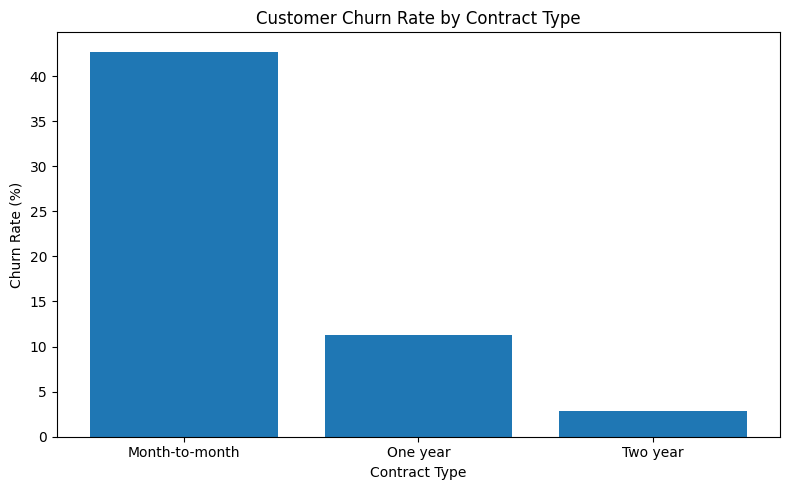

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_analysis["Contract"],
    contract_analysis["churn_rate_%"]
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Contract Type")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tenure

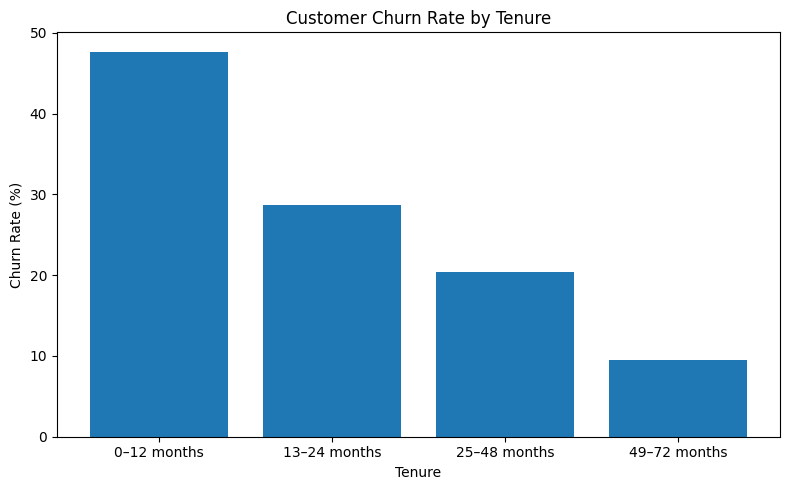

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    tenure_analysis["tenure_group"].astype(str),
    tenure_analysis["churn_rate_%"]
)

plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Tenure")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "churn_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Monthly charges

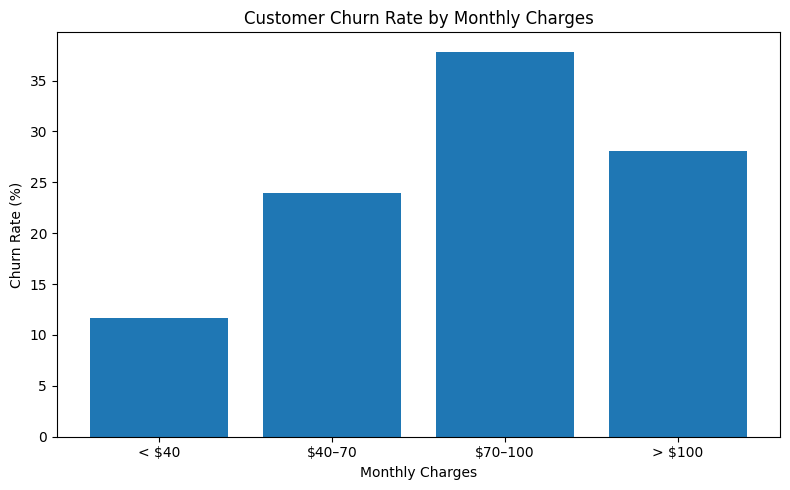

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    charge_analysis["monthly_charge_group"].astype(str),
    charge_analysis["churn_rate_%"]
)

plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Monthly Charges")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "churn_by_monthly_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Prepare the modeling dataset

In [17]:
model_df = df.drop(
    columns=[
        "tenure_group",
        "monthly_charge_group"
    ]
).copy()

print("Modeling dataset:", model_df.shape)

Modeling dataset: (7032, 20)


Separate features and target

In [18]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True).mul(100).round(2))

Features: (7032, 19)
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Target percentage:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


Train/test split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training rows: 5625
Testing rows: 1407

Training target:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target:
Churn
0    1033
1     374
Name: count, dtype: int64


Build the preprocessing pipeline

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\khadd\AppData\Local\Temp\ipykernel_13732\1822984852.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Create preprocessing:

In [21]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

Establish a baseline

In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("NAIVE BASELINE")
print("==============")

print(f"Accuracy : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Precision: {precision_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, baseline_pred, zero_division=0):.4f}")

NAIVE BASELINE
Accuracy : 0.7342
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


Final Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


Evaluate

In [24]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS")
print("=====================")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Stayed", "Churned"]
    )
)

RANDOM FOREST RESULTS
Accuracy : 0.7647
Precision: 0.5413
Recall   : 0.7540
F1-score : 0.6302

Confusion Matrix:
[[794 239]
 [ 92 282]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.77      0.83      1033
     Churned       0.54      0.75      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.78      1407



Feature importance

In [25]:
# Get transformed feature names
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest importance
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15))

,feature,importance
0,categorical__Contract_Month-to-month,0.131947
1,numeric__tenure,0.127666
2,numeric__TotalCharges,0.102497
3,numeric__MonthlyCharges,0.074610
4,categorical__Contract_Two year,0.065009
5,categorical__OnlineSecurity_No,0.059286
6,categorical__TechSupport_No,0.047754
7,categorical__InternetService_Fiber optic,0.043594
8,categorical__PaymentMethod_Electronic check,0.037091
9,categorical__Contract_One year,0.020017


create the final visualization:

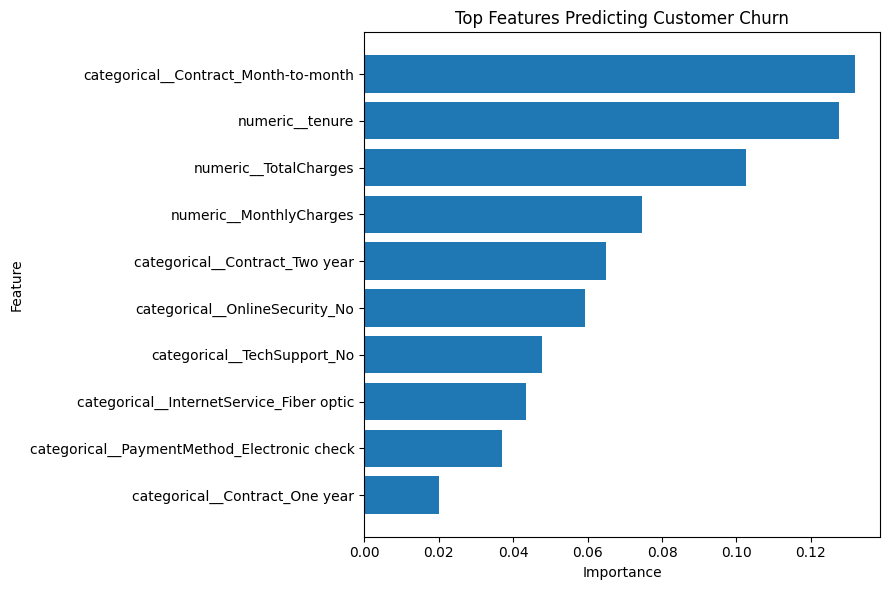

In [26]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Predicting Customer Churn")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save the model

In [27]:
import joblib

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    MODELS_DIR
    / "customer_churn_random_forest.joblib"
)

joblib.dump(
    rf_model,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
..\models\customer_churn_random_forest.joblib


Save the final modeling dataset

In [28]:
final_data_path = (
    PROCESSED_DATA_DIR
    / "customer_churn_modeling_dataset.csv"
)

model_df.to_csv(
    final_data_path,
    index=False
)

print("Modeling dataset saved to:")
print(final_data_path)

Modeling dataset saved to:
..\data\processed\customer_churn_modeling_dataset.csv


Create one final confusion-matrix figure

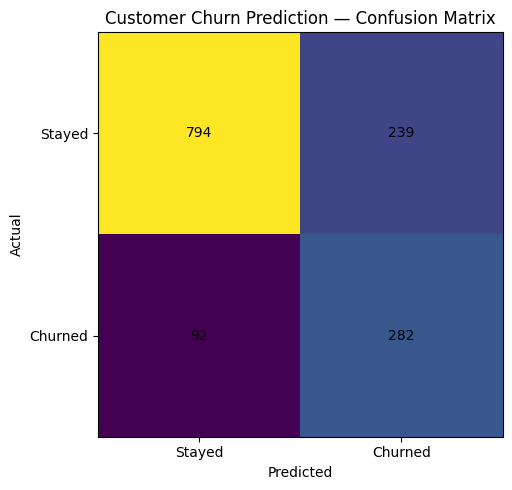

In [29]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Customer Churn Prediction — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Stayed", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Stayed", "Churned"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Verify the saved files

In [30]:
print("Figures:")
for file in FIGURES_DIR.iterdir():
    print(" -", file.name)

print("\nModels:")
for file in MODELS_DIR.iterdir():
    print(" -", file.name)

print("\nProcessed data:")
for file in PROCESSED_DATA_DIR.iterdir():
    print(" -", file.name)

Figures:
 - churn_by_contract.png
 - churn_by_monthly_charges.png
 - churn_by_tenure.png
 - confusion_matrix.png
 - feature_importance.png

Models:
 - customer_churn_random_forest.joblib

Processed data:
 - customer_churn_modeling_dataset.csv
 - telco_customer_churn_clean.csv
